In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import numpy as np
from pathlib import Path

plt.style.use("seaborn-v0_8-darkgrid")

# Localisation du fichier CSV
current_dir = Path().resolve()
project_root = current_dir.parent
data_path = project_root / "Data" / "Dataset of weighing station temperature measurements.csv"

df = pd.read_csv(data_path, sep=";")

# Conversion de la colonne Time en datetime et mise en index
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time").sort_index()

df.head()


,Outdoor temperature [deg. C],Outdoor relative humidity [%],T[degC]-Low-S1,T[degC]-Low-S2,T[degC]-Low-S3,T[degC]-Low-S4,T[degC]-Low-S5,T[degC]-Low-S6,T[degC]-Low-S7,T[degC]-Low-S8,...,T[degC]-Top-S20,T[degC]-Top-S21,T[degC]-Top-S22,T[degC]-Top-S23,T[degC]-Top-S24,T[degC]-Top-S25,T[degC]-Top-S26,T[degC]-Top-S27,T[degC]-Top-S28,T[degC]-Top-S29
Time,,,,,,,,,,,,,,,,,,,,,
2023-12-21 12:10:00,-3.883333,42.333333,33.522705,31.560910,34.793104,30.900530,NaN,22.404998,33.093054,NaN,...,8.361203,14.383413,8.152400,11.794627,0.243417,-0.262979,0.135317,0.686731,-0.371935,0.519350
2023-12-21 12:12:00,-3.880000,42.400000,33.803224,31.345106,35.152043,30.010469,NaN,20.637749,32.470107,NaN,...,7.510757,13.676871,8.008640,11.373162,-0.190435,-0.432580,-0.057492,0.495419,-0.384059,0.387556
2023-12-21 12:14:00,-3.876667,42.466667,33.184819,30.096022,32.640345,28.717193,NaN,19.941584,31.789397,NaN,...,8.691577,14.843329,8.229449,11.859397,0.781753,-0.493263,0.411335,1.067664,-0.335581,0.614961
2023-12-21 12:16:00,-3.873333,42.533333,33.534186,31.024726,33.257158,29.600942,NaN,21.224968,31.869777,NaN,...,10.831607,16.998668,10.048923,13.826938,2.526770,0.913081,2.549498,2.620016,-0.178265,1.800967
2023-12-21 12:18:00,-3.870000,42.600000,34.166208,32.214443,34.975090,31.081814,NaN,22.437115,32.675023,NaN,...,10.396931,16.572248,9.798096,13.483880,2.187975,0.471456,1.553302,2.059153,-0.190359,1.612425


In [43]:
# Colonnes de température à l'intérieur du puits
low_cols = [c for c in df.columns if "Low" in c]
mid_cols = [c for c in df.columns if "Mid" in c]
top_cols = [c for c in df.columns if "Top" in c]

# Fonction pour trier par numéro de sonde S1, S2, ...
def sort_by_sensor(col_list):
    return sorted(col_list, key=lambda x: int(x.split("-S")[1]))

low_cols = sort_by_sensor(low_cols)
mid_cols = sort_by_sensor(mid_cols)
top_cols = sort_by_sensor(top_cols)

# print("Nb sondes LOW :", len(low_cols))
# print("Exemple LOW :", low_cols[:5])


In [44]:
zones_dict = {
    "P1": [1, 2, 3, 4, 5],
    "P2": [6, 7, 8, 9],
    "P3": [10, 11, 12, 13, 14],
    "P4": [15, 16, 17, 18, 19],
    "P5": [20, 21, 22, 23, 24],
    "P6": [25, 26, 27, 28, 29],
}

# Température moyenne sous chaque plateau (LOW + MID + TOP)

plateaux_temp = {}   # dict: "P1" série temporelle

for zone_name, sondes in zones_dict.items():
    # Moyenne horizontale sur les sondes de ce plateau pour chaque hauteur
    T_low = df[[low_cols[s-1] for s in sondes]].mean(axis=1)
    T_mid = df[[mid_cols[s-1] for s in sondes]].mean(axis=1)
    T_top = df[[top_cols[s-1] for s in sondes]].mean(axis=1)
    
    # Moyenne verticale (LOW + MID + TOP)
    T_mean = pd.concat([T_low, T_mid, T_top], axis=1).mean(axis=1)
    
    plateaux_temp[zone_name] = T_mean

# DataFrame final : une colonne par plateau
df_plateaux = pd.DataFrame(plateaux_temp)

# smoothing temporel (30 minutes)
df_plateaux_30min = df_plateaux.resample("30min").mean()

df_plateaux_30min.head()


,P1,P2,P3,P4,P5,P6
Time,,,,,,
2023-12-21 12:00:00,35.437290,26.155066,13.954290,9.101483,8.664824,0.920530
2023-12-21 12:30:00,34.401571,24.829086,12.301379,7.666740,7.232826,0.566213
2023-12-21 13:00:00,34.031843,24.507627,12.271837,7.744770,7.486554,0.701877
2023-12-21 13:30:00,33.283745,23.519815,11.630771,7.404863,7.340771,0.809396
2023-12-21 14:00:00,33.189541,23.152036,11.202735,6.914371,7.040444,0.737533


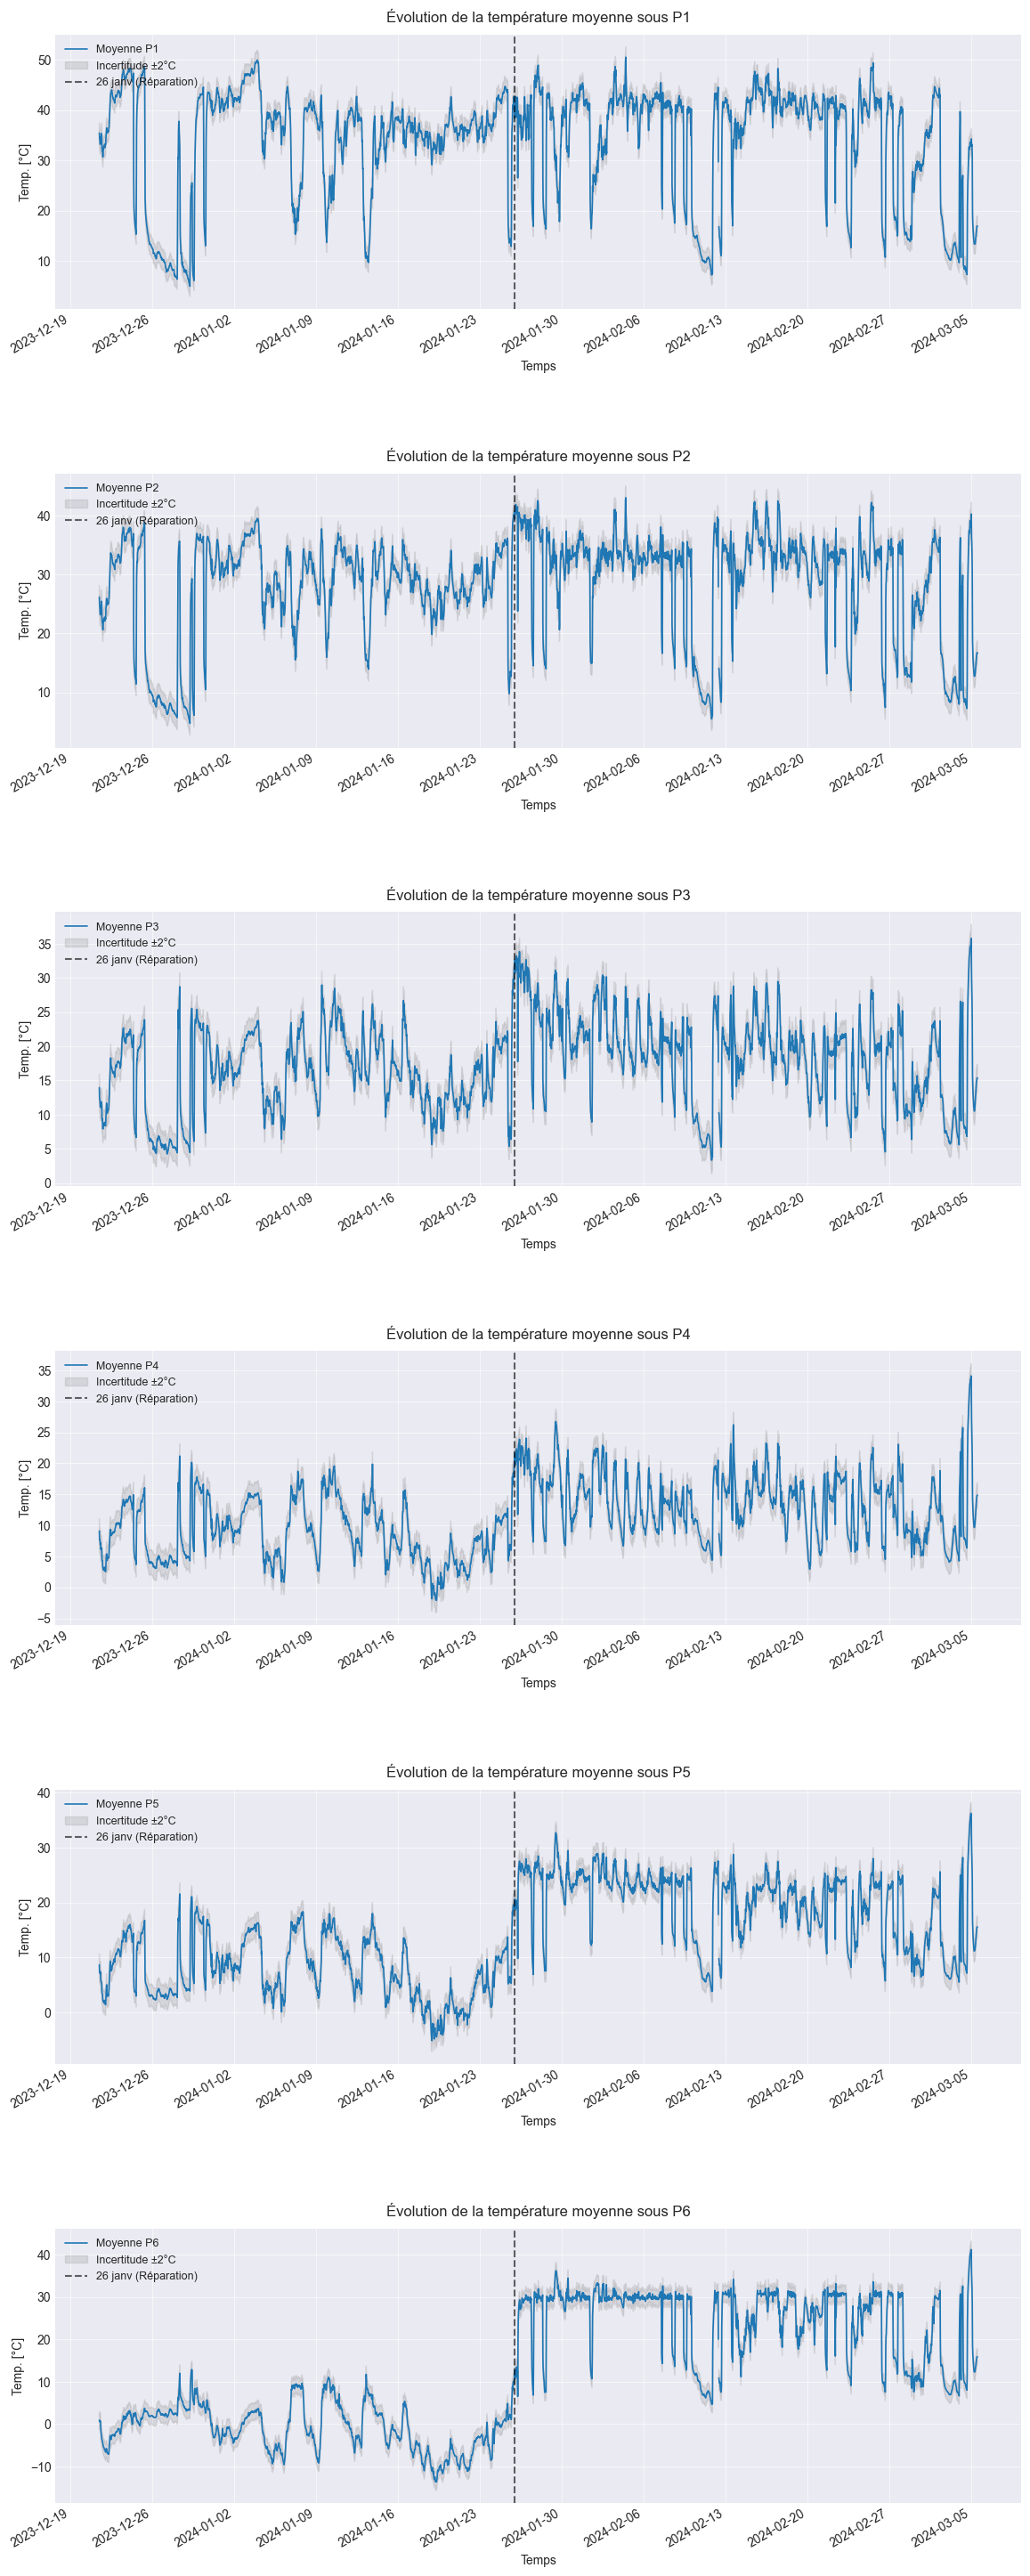

In [49]:
#graph evolution temperature moyenne sous chaque plateau
# Date de la réparation pour la ligne verticale
# Date de la réparation pour la ligne verticale
date_split = dt.datetime(2024, 1, 26)

# Récupération des colonnes
colonnes_plateaux = df_plateaux_30min.columns
nb_plateaux = len(colonnes_plateaux)

# --- CRÉATION DE LA FIGURE ---
# sharex=False : Chaque graphique gère son propre axe X (plus sûr pour l'affichage)
fig, axes = plt.subplots(nrows=nb_plateaux, ncols=1, figsize=(14, 6 * nb_plateaux), sharex=False)

# --- BOUCLE DE TRACÉ ---
for ax, plateau in zip(axes, colonnes_plateaux):
    
    # 1. Courbe
    ax.plot(df_plateaux_30min.index, 
            df_plateaux_30min[plateau],
            label=f"Moyenne {plateau}", 
            linewidth=1.2)
    
    # 2. Bande d'incertitude
    ax.fill_between(df_plateaux_30min.index,
                    df_plateaux_30min[plateau] - 2,
                    df_plateaux_30min[plateau] + 2,
                    color='gray', alpha=0.2, label="Incertitude ±2°C")
    
    # 3. Ligne verticale (Réparation)
    ax.axvline(date_split, color="k", linestyle="--", alpha=0.6, label="26 janv (Réparation)")
    
    # 4. Titres et Grilles
    ax.set_title(f"Évolution de la température moyenne sous {plateau}", fontsize=12, pad=10)
    ax.set_ylabel("Temp. [°C]")
    ax.grid(True, alpha=0.6)
    
    # 5. Gestion explicite de l'axe X (Dates) pour CHAQUE graphique
    ax.set_xlabel("Temps") # On met le label partout
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    
    # Rotation des dates pour ce graphique spécifique
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    
    # Légende (en haut à gauche)
    ax.legend(loc="upper left", fontsize=9)

# --- AJUSTEMENT FINAL ---
# hspace augmente l'espace vertical entre les graphiques pour que les dates ne touchent pas le titre du dessous
plt.subplots_adjust(hspace=0.6)

plt.show()

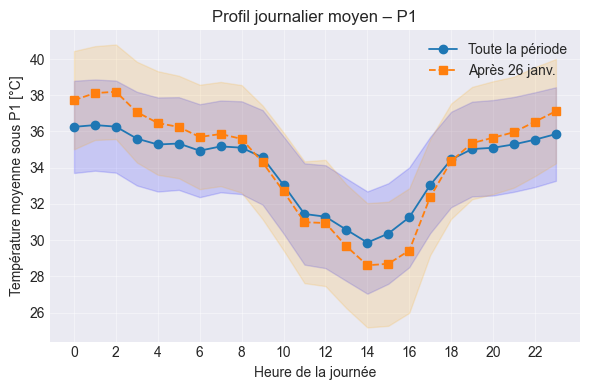

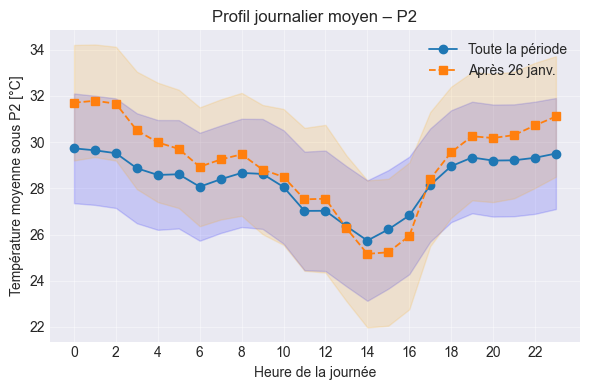

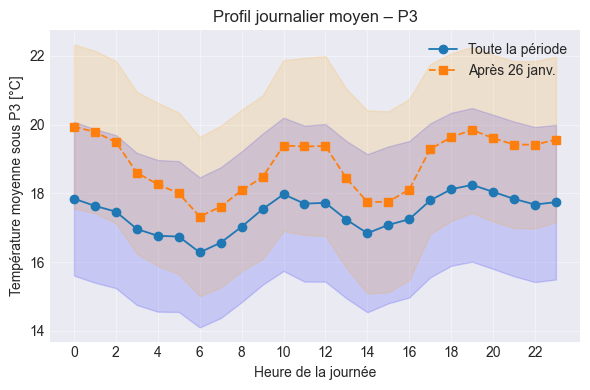

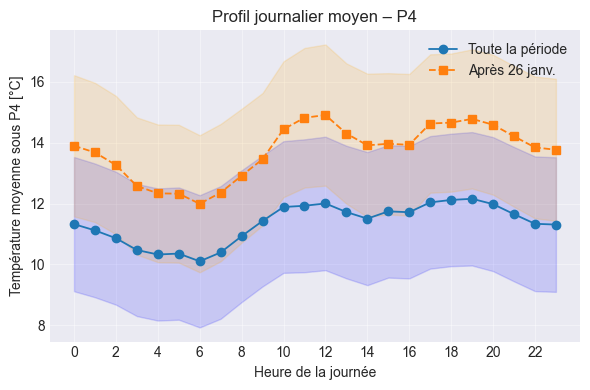

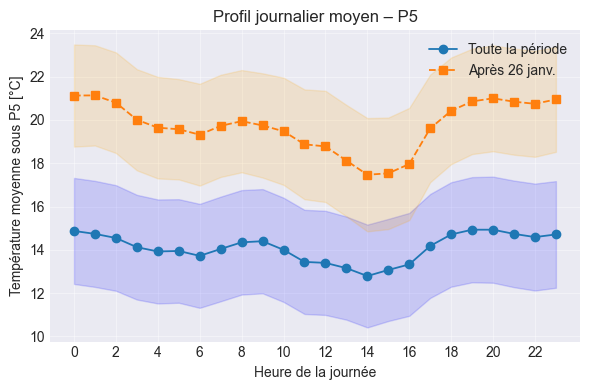

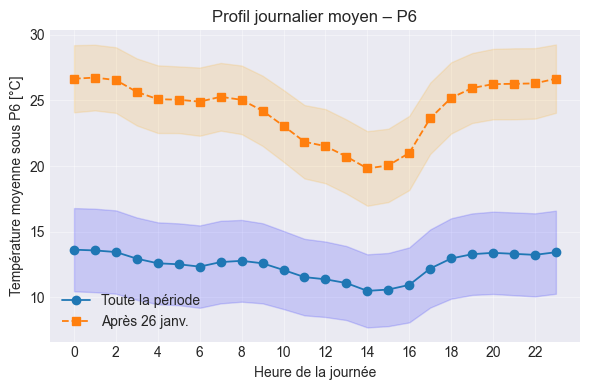

In [46]:
# Profil journalier moyen pour chaque plateau
# Comparaison : toute la période vs après la réparation (26 janvier)

date_split = dt.datetime(2024, 1, 26)

for p in df_plateaux_30min.columns:
    # Série complète pour ce plateau
    serie = df_plateaux_30min[p].dropna()

    # Profil journalier moyen sur toute la période
    grouper_total = serie.groupby(serie.index.hour)
    profil_journee_total = grouper_total.mean()
    
    # Incertitude combinée (Capteur ±2°C + IC 95% sur la moyenne)
    sem_total = grouper_total.std() / np.sqrt(grouper_total.count())
    inc_total = np.sqrt(2.0**2 + (1.96 * sem_total)**2)

    # Profil journalier moyen après le 26 janvier
    serie_apres = serie[serie.index >= date_split]
    grouper_apres = serie_apres.groupby(serie_apres.index.hour)
    profil_journee_apres = grouper_apres.mean()
    
    sem_apres = grouper_apres.std() / np.sqrt(grouper_apres.count())
    inc_apres = np.sqrt(2.0**2 + (1.96 * sem_apres)**2)

    plt.figure(figsize=(6, 4))
    
    # Plot Toute la période avec bande d'incertitude
    plt.plot(
        profil_journee_total.index,
        profil_journee_total.values,
        marker="o",
        linewidth=1.3,
        label="Toute la période",
    )
    plt.fill_between(profil_journee_total.index,
                     profil_journee_total - inc_total,
                     profil_journee_total + inc_total,
                     color='blue', alpha=0.15)

    # Plot Après 26 janv avec bande d'incertitude
    plt.plot(
        profil_journee_apres.index,
        profil_journee_apres.values,
        marker="s",
        linewidth=1.3,
        linestyle="--",
        label="Après 26 janv.",
    )
    plt.fill_between(profil_journee_apres.index,
                     profil_journee_apres - inc_apres,
                     profil_journee_apres + inc_apres,
                     color='orange', alpha=0.15)

    plt.xlabel("Heure de la journée")
    plt.ylabel(f"Température moyenne sous {p} [°C]")
    plt.title(f"Profil journalier moyen – {p}")
    plt.grid(True, alpha=0.4)
    plt.xticks(range(0, 24, 2))  # ticks toutes les 2 h
    plt.legend()
    plt.tight_layout()
    plt.show()

In [47]:
date_split = dt.datetime(2024, 1, 26)

stats_global = {}
stats_avant = {}
stats_apres = {}

for p in df_plateaux_30min.columns:
    # Série complète pour ce plateau (sans NaN)
    s = df_plateaux_30min[p].dropna()

    # Si aucune donnée, on passe
    if s.empty:
        continue

    # --- Statistiques sur toute la période ---
    sem_global = s.sem()
    inc_global = np.sqrt(2.0**2 + (1.96 * sem_global)**2)

    stats_global[p] = {
        "n_global": len(s),
        "mean_global": s.mean(),
        "inc_global": inc_global,
        "std_global":  s.std(),
        "min_global":  s.min(),
        "max_global":  s.max(),
    }

    # --- Séparation avant / après 26 janvier ---
    s_av = s[s.index < date_split]
    s_ap = s[s.index >= date_split]

    # Avant 26 janvier
    sem_avant = s_av.sem() if not s_av.empty else 0
    inc_avant = np.sqrt(2.0**2 + (1.96 * sem_avant)**2) if not s_av.empty else 0

    stats_avant[p] = {
        "n_avant":   len(s_av),
        "mean_avant": s_av.mean() if not s_av.empty else float("nan"),
        "inc_avant": inc_avant,
        "min_avant":  s_av.min()  if not s_av.empty else float("nan"),
        "max_avant":  s_av.max()  if not s_av.empty else float("nan"),
    }

    # Après 26 janvier
    sem_apres = s_ap.sem() if not s_ap.empty else 0
    inc_apres = np.sqrt(2.0**2 + (1.96 * sem_apres)**2) if not s_ap.empty else 0

    stats_apres[p] = {
        "n_apres":   len(s_ap),
        "mean_apres": s_ap.mean() if not s_ap.empty else float("nan"),
        "inc_apres": inc_apres,
        "min_apres":  s_ap.min()  if not s_ap.empty else float("nan"),
        "max_apres":  s_ap.max()  if not s_ap.empty else float("nan"),
    }

# Création des DataFrames individuels
df_stats_globale = pd.DataFrame(stats_global).T
df_stats_avant   = pd.DataFrame(stats_avant).T
df_stats_apres   = pd.DataFrame(stats_apres).T

# Fusion en un seul tableau
df_stats = pd.concat(
    [df_stats_globale, df_stats_avant, df_stats_apres],
    axis=1
)

# Ajout des deltas après - avant (utile pour le commentaire dans le rapport)
df_stats["delta_mean_apres_avant"] = df_stats["mean_apres"] - df_stats["mean_avant"]
df_stats["delta_min_apres_avant"]  = df_stats["min_apres"]  - df_stats["min_avant"]
df_stats["delta_max_apres_avant"]  = df_stats["max_apres"]  - df_stats["max_avant"]

# Arrondi pour un affichage propre
df_stats_rounded = df_stats.round(2)

print("Tableau synthèse des statistiques par plateau (°C)")
display(df_stats_rounded)

Tableau synthèse des statistiques par plateau (°C)


,n_global,mean_global,inc_global,std_global,min_global,max_global,n_avant,mean_avant,inc_avant,min_avant,max_avant,n_apres,mean_apres,inc_apres,min_apres,max_apres,delta_mean_apres_avant,delta_min_apres_avant,delta_max_apres_avant
P1,3603.0,34.04,2.03,11.01,4.98,50.52,1704.0,33.72,2.07,4.98,49.93,1899.0,34.33,2.06,7.22,50.52,0.61,2.24,0.59
P2,3603.0,28.32,2.02,8.79,4.74,43.02,1704.0,27.43,2.04,4.74,40.76,1899.0,29.11,2.04,5.49,43.02,1.68,0.75,2.26
P3,3603.0,17.42,2.01,6.29,3.33,35.79,1704.0,15.83,2.02,4.25,31.65,1899.0,18.86,2.02,3.33,35.79,3.03,-0.92,4.14
P4,3603.0,11.35,2.01,5.53,-2.09,34.12,1704.0,8.70,2.01,-2.09,21.18,1899.0,13.73,2.01,2.92,34.12,5.03,5.01,12.94
P5,3603.0,14.11,2.02,8.46,-5.13,36.25,1704.0,7.84,2.02,-5.13,21.56,1899.0,19.73,2.02,3.81,36.25,11.89,8.94,14.69
P6,3603.0,12.45,2.05,14.39,-13.64,41.19,1704.0,-0.76,2.02,-13.64,12.87,1899.0,24.31,2.03,4.70,41.19,25.07,18.35,28.32
